In [1]:
import csv
import sys
import random
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

import distanceclosure as dc
from distanceclosure.dijkstra import single_source_dijkstra_path_length

In [2]:
add_probability = 1.0

input_file = '../../confidence_rank_ultrametric.csv'

MANUAL_FIXES = [('FOXP3', 'TGFB')]


In [3]:
def get_U_from_file(input_file):
    df = pd.read_csv(input_file)

    U = nx.DiGraph()

    weighted_edges = df[
        ["Regulator", "Target", "Confidence Rank"]
    ].itertuples(index=False, name=None)

    U.add_weighted_edges_from(weighted_edges, weight="distance")

    print(f"U: {U.number_of_nodes()} nodes, {U.number_of_edges()} edges")

    return U

In [4]:
def get_G_from_U(U, add_probability, assign_rank):
    regulators = set(U.nodes())

    excluded_targets = {
        "IKB", "IL7R", "CD28", "TCR", "NOTCH1",
        "IFNAR", "IFNBR", "IL15R", "IL27R", "IL29R", "IL36R"
    }

    # Source nodes cannot be targets
    source_nodes = {
        node for node in U.nodes()
        if U.in_degree(node) == 0
    }

    targets = set(U.nodes()) - excluded_targets - source_nodes

    n_possible = len(regulators) * len(targets)
    n_existing = U.number_of_edges()

    print(f"Number of regulators: {len(regulators)}")
    print(f"Number of targets: {len(targets)}")
    print(f"Possible regulator-target pairs: {n_possible}")
    print(f"Existing regulator-target pairs: {n_existing}")

    existing_pairs = set(U.edges())

    G = U.copy()

    new_edges = []

    for regulator in regulators:
        for target in targets:
            if (regulator, target) not in existing_pairs:
                if random.random() <= add_probability:
                    new_edges.append((regulator, target, assign_rank))

    G.add_weighted_edges_from(new_edges, weight="distance")

    print(f"Created {len(new_edges)} fake edges.")
    print(f"G: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    return G

In [5]:
def print_report(graph):
    print(f"Number of nodes: {graph.number_of_nodes()}")
    print(f"Number of edges: {graph.number_of_edges()}")
    print(f"Number of self-loops: {len([e for e in graph.edges() if e[0] == e[1]])}")
    max_in_degree = 0
    max_in_degree_node = None
    log2_number_of_possible_BN = 1
    for node in graph.nodes():
        log2_number_of_possible_BN += 2**graph.in_degree(node)

        if graph.in_degree(node) > max_in_degree:
            max_in_degree = graph.in_degree(node)
            max_in_degree_node = node
    print("node with highest in-degree: ", max_in_degree_node, " with in-degree: ", max_in_degree)
    print("number of possible Boolean Networks: 2^", log2_number_of_possible_BN)

In [6]:
# --- Helper to process bottleneck cycles per graph ---
def get_bottleneck_cycles(graph, target_nodes):
    # Storage format: { target_node: { neighbor: (path_tuple, max_weight) } }
    results = {}
    
    for node in target_nodes:
        if node not in graph:
            continue
        results[node] = {}
        
        # 1. Capture standalone self-loops directly
        if graph.has_edge(node, node):
            results[node][node] = ((node, node), graph[node][node].get('distance'))
            
        # 2. Use your Dijkstra function to find the minimax return path from successors
        for neighbor in graph.successors(node):
            if neighbor == node:
                continue
                
            paths = {neighbor: [neighbor]}
            weight_fn = lambda v, u, e: e.get('distance')
            
            try:
                # Find the path that minimizes the maximum edge weight back to 'node'
                dist = single_source_dijkstra_path_length(
                    graph, 
                    source=neighbor, 
                    weight_function=weight_fn, 
                    paths=paths, 
                    disjunction=max
                )
                
                # If the target node was reached, a valid optimal bottleneck cycle exists
                if node in dist:
                    path_back = paths[node]
                    full_cycle = [node] + path_back
                    
                    # Total bottleneck is the max of the exit edge and the path back
                    exit_edge_w = graph[node][neighbor].get('distance')
                    cycle_max_w = max(exit_edge_w, dist[node])
                    
                    results[node][neighbor] = (tuple(full_cycle), cycle_max_w)
            except (nx.NodeNotFound, ValueError):
                continue
                
    return results

In [7]:
def check_cycles(cycles_G, cycles_B):
    errors = []

    for node in set(cycles_G) | set(cycles_B):
        g_routes = cycles_G.get(node, {})
        b_routes = cycles_B.get(node, {})

        # 1. Every cycle in B must also exist in G with the same weight
        for neighbor, (b_path, b_weight) in b_routes.items():
            g_route = g_routes.get(neighbor)

            if g_route is None:
                errors.append(
                    f"Node '{node}': cycle via '{neighbor}' "
                    f"exists in B but is missing in G."
                )
                continue

            g_path, g_weight = g_route

            if g_weight != b_weight:
                errors.append(
                    f"Node '{node}': cycle via '{neighbor}' has "
                    f"different weights: G={g_weight}, B={b_weight}."
                )

        # 2. Global minimum cycle weight must agree
        if g_routes and b_routes:
            min_weight_G = min(w for path, w in g_routes.values())
            min_weight_B = min(w for path, w in b_routes.values())

            if min_weight_G != min_weight_B:
                errors.append(
                    f"Node '{node}': minimum cycle weight differs: "
                    f"G={min_weight_G}, B={min_weight_B}."
                )

        elif g_routes and not b_routes:
            errors.append(
                f"Node '{node}': G has cycles but B has none."
            )

    return errors

In [8]:
def find_self_edges_to_restore(G, B, cycles_G):
    self_edges_to_restore = []

    for node in G.nodes:
        if not G.has_edge(node, node):
            continue

        if B.has_edge(node, node):
            continue

        g_routes = cycles_G.get(node, {})
        if not g_routes:
            continue

        min_weight_G = min(weight for path, weight in g_routes.values())
        self_weight_G = G[node][node].get("distance")

        if self_weight_G == min_weight_G:
            self_edges_to_restore.append(
                (node, node, G[node][node])
            )
            print(f"Found self-edge to restore: {node}, weight: {self_weight_G}")

    return self_edges_to_restore

In [9]:
results = {}

for i in range(5):
    print(f"\nProcessing {input_file}")

    U = get_U_from_file(input_file)

    print_report(U)

    results[i+1] = {
        "file": i+1,
        "U": U,
    }

print(f"\nProcessed {len(results)} files.")


Processing ../../confidence_rank_ultrametric.csv
U: 106 nodes, 292 edges
Number of nodes: 106
Number of edges: 292
Number of self-loops: 5
node with highest in-degree:  IFNG_2  with in-degree:  14
number of possible Boolean Networks: 2^ 31638

Processing ../../confidence_rank_ultrametric.csv
U: 106 nodes, 292 edges
Number of nodes: 106
Number of edges: 292
Number of self-loops: 5
node with highest in-degree:  IFNG_2  with in-degree:  14
number of possible Boolean Networks: 2^ 31638

Processing ../../confidence_rank_ultrametric.csv
U: 106 nodes, 292 edges
Number of nodes: 106
Number of edges: 292
Number of self-loops: 5
node with highest in-degree:  IFNG_2  with in-degree:  14
number of possible Boolean Networks: 2^ 31638

Processing ../../confidence_rank_ultrametric.csv
U: 106 nodes, 292 edges
Number of nodes: 106
Number of edges: 292
Number of self-loops: 5
node with highest in-degree:  IFNG_2  with in-degree:  14
number of possible Boolean Networks: 2^ 31638

Processing ../../confid

In [10]:
for name, result in results.items():
    print(f"\nProcessing {name}")
    U = result["U"]

    G = get_G_from_U(U, add_probability=add_probability, assign_rank=int(name))

    result["G"] = G

    print_report(G)


Processing 1
Number of regulators: 106
Number of targets: 72
Possible regulator-target pairs: 7632
Existing regulator-target pairs: 292
Created 7353 fake edges.
G: 106 nodes, 7645 edges
Number of nodes: 106
Number of edges: 7645
Number of self-loops: 72
node with highest in-degree:  BCL6  with in-degree:  106
number of possible Boolean Networks: 2^ 5841333965851681082096808370372658

Processing 2
Number of regulators: 106
Number of targets: 72
Possible regulator-target pairs: 7632
Existing regulator-target pairs: 292
Created 7353 fake edges.
G: 106 nodes, 7645 edges
Number of nodes: 106
Number of edges: 7645
Number of self-loops: 72
node with highest in-degree:  BCL6  with in-degree:  106
number of possible Boolean Networks: 2^ 5841333965851681082096808370372658

Processing 3
Number of regulators: 106
Number of targets: 72
Possible regulator-target pairs: 7632
Existing regulator-target pairs: 292
Created 7353 fake edges.
G: 106 nodes, 7645 edges
Number of nodes: 106
Number of edges: 7

In [11]:
for name, result in results.items():
    print(f"\nProcessing {name}")
    G = result["G"]

    B = dc.ultrametric_backbone(G, weight='distance', self_loops=False)
    result["B"] = B

    print_report(B)


Processing 1
Number of nodes: 106
Number of edges: 7526
Number of self-loops: 0
node with highest in-degree:  BCL6  with in-degree:  105
number of possible Boolean Networks: 2^ 2155006020387989982544395449139250

Processing 2
Number of nodes: 106
Number of edges: 3078
Number of self-loops: 0
node with highest in-degree:  IL12RB2  with in-degree:  105
number of possible Boolean Networks: 2^ 253530120045645880309830024953906

Processing 3
Number of nodes: 106
Number of edges: 1653
Number of self-loops: 0
node with highest in-degree:  IL1R  with in-degree:  105
number of possible Boolean Networks: 2^ 111553252820084187331710108434482

Processing 4
Number of nodes: 106
Number of edges: 1419
Number of self-loops: 0
node with highest in-degree:  IL25  with in-degree:  105
number of possible Boolean Networks: 2^ 162259276829213363391578044215346

Processing 5
Number of nodes: 106
Number of edges: 996
Number of self-loops: 0
node with highest in-degree:  IFNG_2  with in-degree:  24
number of 

In [12]:
for name, result in results.items():
    print(f"\nProcessing {name}")
    G = result["G"]

    B = result["B"]
    
    target_nodes = [
        n for n in set(list(G.nodes()) + list(B.nodes()))
        if G.has_edge(n, n) or B.has_edge(n, n)
    ]

    print(f"{len(target_nodes)} target nodes:", target_nodes)

    # Storage format: { target_node: { neighbor: (path_tuple, max_weight) } }
    cycles_G = get_bottleneck_cycles(G, target_nodes)
    cycles_B = get_bottleneck_cycles(B, target_nodes)

    result["cycles_G"] = cycles_G
    result["cycles_B"] = cycles_B

    errors = check_cycles(cycles_G, cycles_B)

    if errors:
        print("Cycle check failed:")
        for error in errors:
            print(" -", error)
    else:
        print("Cycle check passed.")



Processing 1
72 target nodes: ['IL25R', 'IL2', 'IL25', 'IL33R', 'IL35', 'IL6R', 'EOMES', 'ST2', 'IL2RA', 'IL4RA_2', 'proliferation', 'IL2R', 'TBET', 'IL4', 'IL22', 'STAT5', 'GZMB', 'THPOK', 'IL23', 'TBET_2', 'IL4R', 'NFAT', 'JAK1', 'IL2R_2', 'IFNGR_2', 'GATA3', 'IL10R', 'PU1', 'STAT1', 'IFNG_2', 'SOCS1', 'STAT3', 'IL5', 'IL1R1', 'TGFBR', 'IL21', 'IL18R', 'RUNX3', 'FOXP3', 'RORGT', 'IL12R', 'TGFB', 'IL12RB2', 'IFNGR', 'CD4', 'IL17', 'CMAF', 'IL1R', 'PRF1', 'IFNG', 'IRF1', 'IL9', 'NFKB', 'IL21R', 'IL3', 'IL10', 'STAT1_2', 'IL12RB1_2', 'IRAK', 'IL31', 'STAT4', 'SMAD3', 'IL24', 'BCL6', 'IL23R', 'STAT6', 'SMAD2', 'CD8', 'IL4R_2', 'STAT5_2', 'IL6', 'IL13']
Cycle check passed.

Processing 2
72 target nodes: ['IL25R', 'IL2', 'IL25', 'IL33R', 'IL35', 'IL6R', 'EOMES', 'ST2', 'IL2RA', 'IL4RA_2', 'proliferation', 'IL2R', 'TBET', 'IL4', 'IL22', 'STAT5', 'GZMB', 'THPOK', 'IL23', 'TBET_2', 'IL4R', 'NFAT', 'JAK1', 'IL2R_2', 'IFNGR_2', 'GATA3', 'IL10R', 'PU1', 'STAT1', 'IFNG_2', 'SOCS1', 'STAT3', 'IL5

In [13]:
for name, result in results.items():
    print(f"\nProcessing {name}")
    G = result["G"]
    B = result["B"]
    cycles_G = result["cycles_G"]

    self_edges_to_restore = find_self_edges_to_restore(
        G, B, cycles_G
    )

    B2 = B.copy()
    B2.add_edges_from(self_edges_to_restore)

    cycles_B2 = get_bottleneck_cycles(B2, target_nodes)

    errors = check_cycles(cycles_G, cycles_B2)

    if errors:
        print("Cycle check failed:")
        for error in errors:
            print(" -", error)
    else:
        print("Cycle check passed.")

    self_edges_to_restore = find_self_edges_to_restore(
        G, B2, cycles_G
    )

    if self_edges_to_restore:
        print(f"Found {len(self_edges_to_restore)} self-edges to restore.")
    else:
        print("No self-edges to restore.")

    print_report(B2)

    result["B2"] = B2
    result["cycles_B2"] = cycles_B2


Processing 1
Found self-edge to restore: BCL6, weight: 1
Found self-edge to restore: GATA3, weight: 1
Found self-edge to restore: IFNG, weight: 1
Found self-edge to restore: IFNG_2, weight: 1
Found self-edge to restore: IL21, weight: 1
Found self-edge to restore: TBET, weight: 1
Found self-edge to restore: TBET_2, weight: 1
Found self-edge to restore: NFAT, weight: 1
Found self-edge to restore: CD4, weight: 1
Found self-edge to restore: THPOK, weight: 1
Found self-edge to restore: CD8, weight: 1
Found self-edge to restore: RUNX3, weight: 1
Found self-edge to restore: CMAF, weight: 1
Found self-edge to restore: IL10, weight: 1
Found self-edge to restore: IL22, weight: 1
Found self-edge to restore: IL4, weight: 1
Found self-edge to restore: EOMES, weight: 1
Found self-edge to restore: GZMB, weight: 1
Found self-edge to restore: PRF1, weight: 1
Found self-edge to restore: FOXP3, weight: 1
Found self-edge to restore: IL2, weight: 1
Found self-edge to restore: IL2RA, weight: 1
Found self-e

In [14]:
for name, result in results.items():
    print(f"\nProcessing {name}")
    G = result["G"]
    B = result["B"]
    B2 = result["B2"]

    B3 = B2.copy()
    if MANUAL_FIXES:
        print(f"Adding {len(MANUAL_FIXES)} edges back into Graph B...")

        edges_to_add = []
        for edge in MANUAL_FIXES:
            u, v = edge
            edges_to_add.append((u, v, G[u][v]))

        B3.add_edges_from(edges_to_add)
        
        # Recalculate bottleneck paths for B now that it has been altered
        cycles_B_updated = get_bottleneck_cycles(B3, target_nodes)
    else:
        print("No target nodes triggered the condition. Graph B remains unchanged.")

    print_report(B3)

    result["B3"] = B3


Processing 1
Adding 1 edges back into Graph B...
Number of nodes: 106
Number of edges: 7598
Number of self-loops: 71
node with highest in-degree:  BCL6  with in-degree:  106
number of possible Boolean Networks: 2^ 4289729631172328294664843646992434

Processing 2
Adding 1 edges back into Graph B...
Number of nodes: 106
Number of edges: 3107
Number of self-loops: 28
node with highest in-degree:  IL12RB2  with in-degree:  106
number of possible Boolean Networks: 2^ 507060240091291760612109497401394

Processing 3
Adding 1 edges back into Graph B...
Number of nodes: 106
Number of edges: 1675
Number of self-loops: 21
node with highest in-degree:  IL1R  with in-degree:  106
number of possible Boolean Networks: 2^ 223106505640168374663420062990386

Processing 4
Adding 1 edges back into Graph B...
Number of nodes: 106
Number of edges: 1439
Number of self-loops: 19
node with highest in-degree:  IL25  with in-degree:  106
number of possible Boolean Networks: 2^ 324518553658426726783156059090994


In [17]:
import matplotlib.pyplot as plt
import pandas as pd

categories = []

for key in [1, 2, 3, 4, 5]:
    U = set(results[key]["U"].edges())
    G = set(results[key]["G"].edges())
    B3 = set(results[key]["B3"].edges())

    categories.append({
        "key": key,

        # 1. U, retained in B3
        "U retained": len(U & B3),

        # 2. G but not U, retained in B3
        "G-only retained": len((G - U) & B3),

        # 3. G but not U, lost in B3
        "G-only lost": len((G - U) - B3),

        # 4. U, lost in B3
        "U lost": len(U - B3),
    })

plot_df = pd.DataFrame(categories)

plot_df

,key,U retained,G-only retained,G-only lost,U lost
0,1,245,7353,0,47
1,2,267,2840,4513,25
2,3,271,1404,5949,21
3,4,292,1147,6206,0
4,5,292,720,6633,0


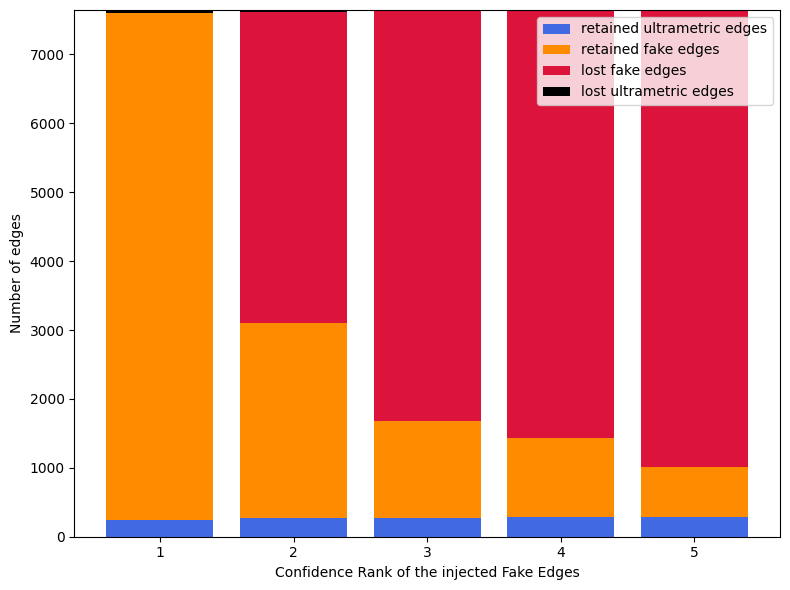

In [23]:
plt.figure(figsize=(8, 6))

plt.bar(
    plot_df["key"],
    plot_df["U retained"],
    label="retained ultrametric edges",
    color="royalblue"
)

plt.bar(
    plot_df["key"],
    plot_df["G-only retained"],
    bottom=plot_df["U retained"],
    label="retained fake edges",
    color="darkorange"
)

plt.bar(
    plot_df["key"],
    plot_df["G-only lost"],
    bottom=(
        plot_df["U retained"]
        + plot_df["G-only retained"]
    ),
    label="lost fake edges",
    color="crimson"
)

plt.bar(
    plot_df["key"],
    plot_df["U lost"],
    bottom=(
        plot_df["U retained"]
        + plot_df["G-only retained"]
        + plot_df["G-only lost"]
    ),
    label="lost ultrametric edges",
    color="black"
)

plt.xlabel("Confidence Rank of the injected Fake Edges")
plt.ylabel("Number of edges")
plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.tight_layout()
plt.show()